In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [2]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
print("Duplicate rows:", df.duplicated().sum())

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Postal Code'] = df['Postal Code'].astype(str)

df.info()

Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   object        
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub

                     Sales     Profit
Category                             
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95


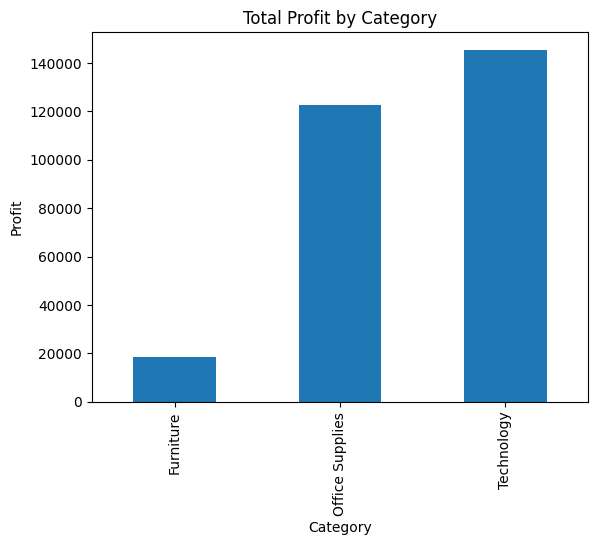

             Sales     Profit
Region                       
Central  501239.89   39706.36
East     678781.24   91522.78
South    391721.90   46749.43
West     725457.82  108418.45


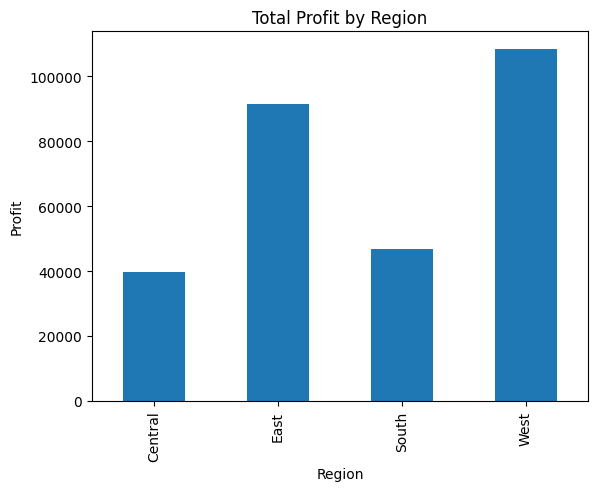

In [5]:
import matplotlib.pyplot as plt

# Q1: Which category earns the most profit?
cat = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
print(cat)
cat['Profit'].plot(kind='bar', title='Total Profit by Category')
plt.ylabel('Profit')
plt.show()

# Q2: Which region performs best?
reg = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
print(reg)
reg['Profit'].plot(kind='bar', title='Total Profit by Region')
plt.ylabel('Profit')
plt.show()

**Finding 1: Category**

Technology earns the most profit (145,454.95) at a 17.4% margin, and Office Supplies is close behind at 17.0%.
Furniture has the second-highest sales (741,999.80) but the lowest profit (18,451.27), a margin of only 2.5%. It sells well but barely makes money.

**Finding 2: Region**

West is the top region, with the highest sales (725,457.82) and profit (108,418.45), at a 14.9% margin.
Central makes 39,706.36 profit on 501,239.89 sales, a 7.9% margin. That's the weakest margin, even though it sells more than South, whose margin is 11.9%.

          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000
Discount
0.00     66.90
0.10     96.06
0.15     27.29
0.20     24.70
0.30    -45.68
0.32    -88.56
0.40   -111.93
0.45   -226.65
0.50   -310.70
0.60    -43.08
0.70    -95.87
0.80   -101.80
Name: Profit, dtype: float64


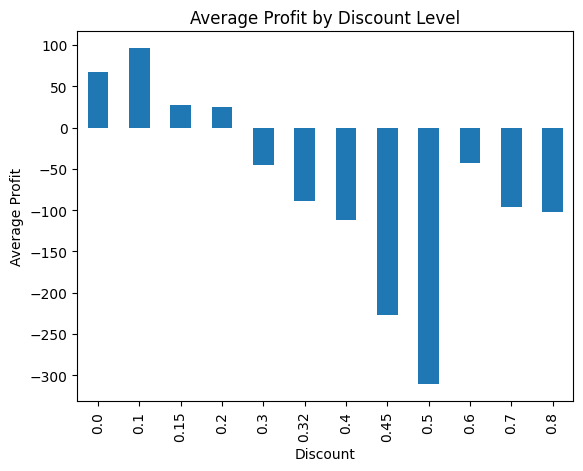

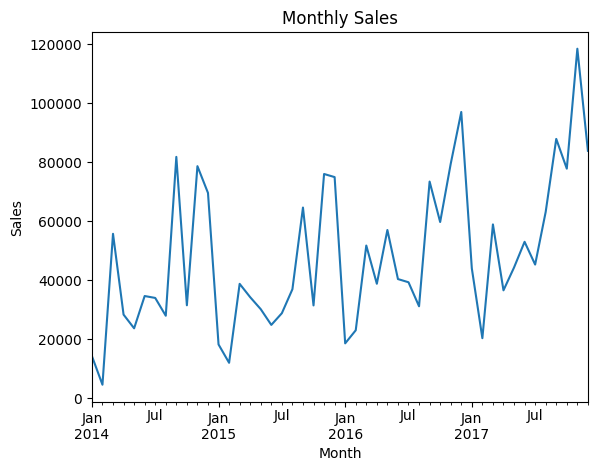

In [7]:
# Q3: Does a higher discount lower profit?
print(df[['Discount', 'Profit']].corr())
disc = df.groupby('Discount')['Profit'].mean().round(2)
print(disc)
disc.plot(kind='bar', title='Average Profit by Discount Level')
plt.ylabel('Average Profit')
plt.show()

# Q4: Monthly sales trend
df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum()
monthly.plot(title='Monthly Sales')
plt.ylabel('Sales')
plt.show()

**Finding 3: Discounts.** Discount and profit have a negative correlation of -0.22, so higher discounts tend to go with lower profit. Orders with discounts up to 20% still make money on average (24.70 to 96.06 per order). From 30% upward, the average order loses money (-45.68 at 30%), and the worst losses come at 45% (-226.65) and 50% (-310.70). Discounts above 20% are the point where the store starts losing money.

**Finding 4: Monthly sales.** Yearly sales fell slightly in 2015 (470,532.51, down 2.8% from 484,247.50 in 2014), then grew to 609,205.60 in 2016 (+29.5%) and 733,215.26 in 2017 (+20.4%), a 51% rise from 2014 to 2017. Sales are also seasonal: all five of the best months fall between September and December, with November 2017 the highest at 118,447.82.

In [8]:
df['Year'] = df['Order Date'].dt.year
print(df.groupby('Year')['Sales'].sum().round(2))
print(monthly.sort_values(ascending=False).head(5).round(2))

Year
2014    484247.50
2015    470532.51
2016    609205.60
2017    733215.26
Name: Sales, dtype: float64
Month
2017-11    118447.82
2016-12     96999.04
2017-09     87866.65
2017-12     83829.32
2014-09     81777.35
Freq: M, Name: Sales, dtype: float64


## Conclusion

- **Profit drivers:** Technology and Office Supplies earn healthy margins (about 17%), while Furniture makes only about 2.5% despite strong sales.
- **Regions:** West is the strongest region. Central has the weakest margin (7.9%).
- **Discounts:** Orders discounted above 20% lose money on average, so discounts should be capped near 20%.
- **Growth and seasonality:** Sales grew 51% from 2014 to 2017 and peak between September and December, so stock and promotions should be planned for that period.